In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

from scipy.ndimage import binary_dilation, binary_erosion
from skimage.morphology import opening, closing
from skimage.morphology import disk

In [2]:
square_5 = np.zeros((11,11))
square_5[3:8, 3:8] = 1               # 5x5 square

plus_sign = np.zeros((11, 11))
plus_sign[3:8, 5] = 1
plus_sign[5, 3:8] = 1               # plus sign - 1 box thick

donut = np.zeros((20, 20))
donut[5:15, 5:15] = 1
donut[7:13, 7:13] = 0               # 10 X 10 with hole in middle

dumbell = np.zeros((21, 21))
dumbell[8:13, 4:9] = 1
dumbell[8:13, 12:17] = 1
dumbell[10, 9:12] = 1               # dumbell

# ==================================================================
kernel_square_5 = np.zeros((11,11))
kernel_square_5[3:8, 3:8] = 1                       # 5x5 square

kernel_square_2 = np.zeros((10,10))
kernel_square_2[4:6, 4:6] = 1                       # 2 X 2 square

kernel_rectangle_21 = np.zeros((10,10))
kernel_rectangle_21[5:6, 4:6] = 1                   # 2 X 1 rectangle


In [3]:
def morphological_op(template, strel):
    dilation = binary_dilation(template, structure = strel)
    erosion = binary_erosion(template, structure = strel)
    return dilation, erosion

# plotting

def morphological_op_plot(template):
    structures = [kernel_square_2, kernel_rectangle_21, kernel_square_5]
    fig, ax = plt.subplots(len(structures), 4, figsize = (12, 9), tight_layout = True)
    
    for i, strel in enumerate(structures):
        ax[i,0].imshow(template, cmap = "gray")
        ax[i,1].imshow(strel, cmap = "gray")
        ax[i,2].imshow(morphological_op(template, strel)[0], cmap = "gray")
        ax[i,3].imshow(morphological_op(template, strel)[1], cmap = "gray")

    ax[0,0].set_title("Original element")
    ax[0,1].set_title("Structuring element")
    ax[0,2].set_title("Dilation")
    ax[0,3].set_title("Erosion")

    ax = ax.flatten()
    for a in ax:
        a.axis("off")

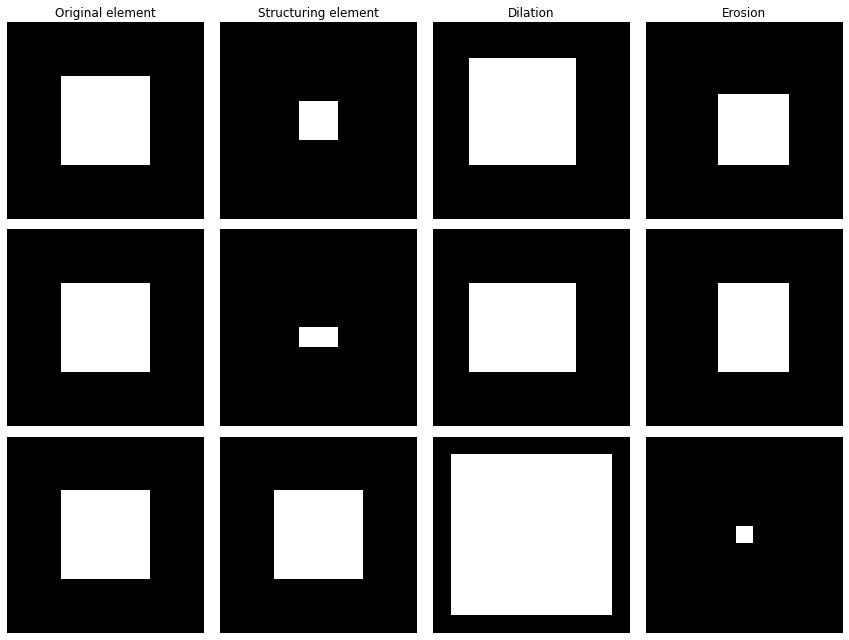

In [4]:
morphological_op_plot(square_5)

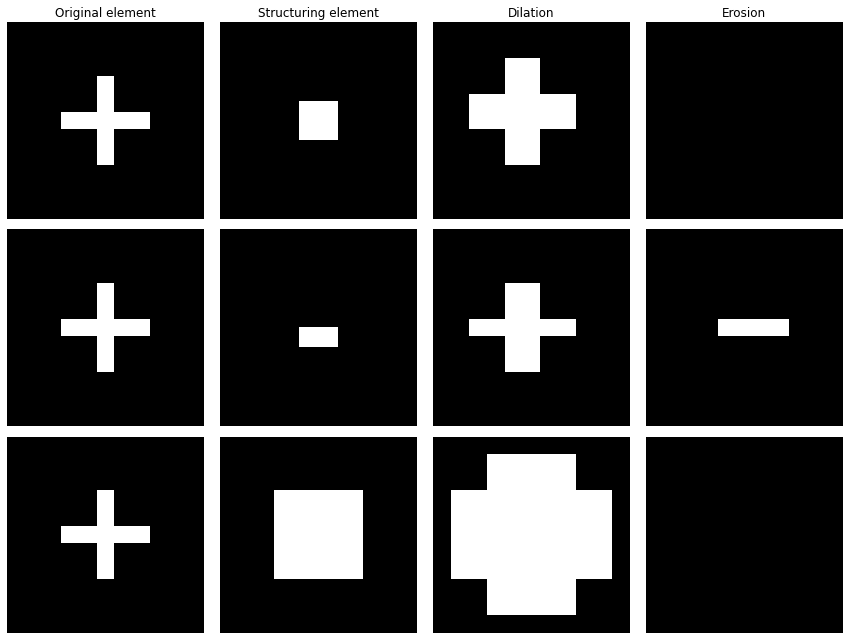

In [5]:
morphological_op_plot(plus_sign)

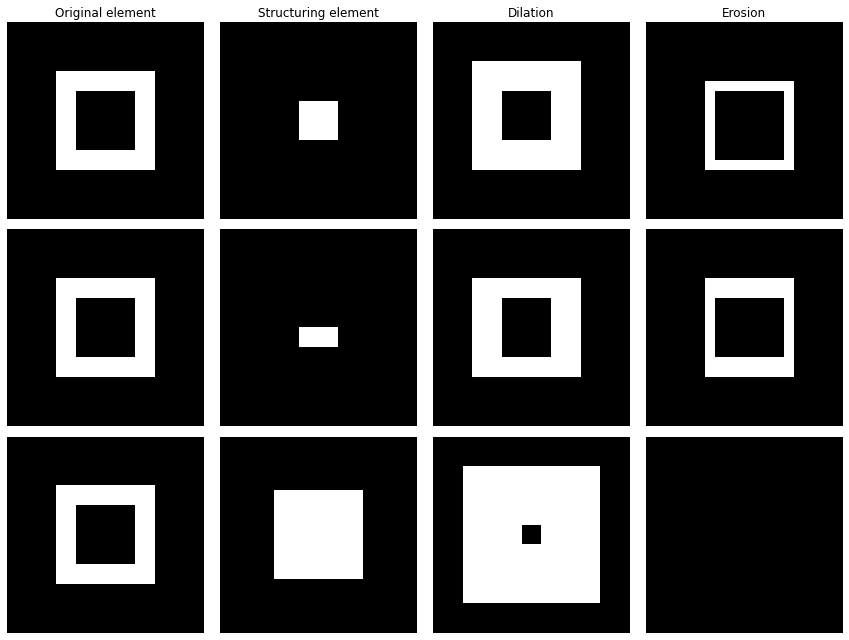

In [6]:
morphological_op_plot(donut)

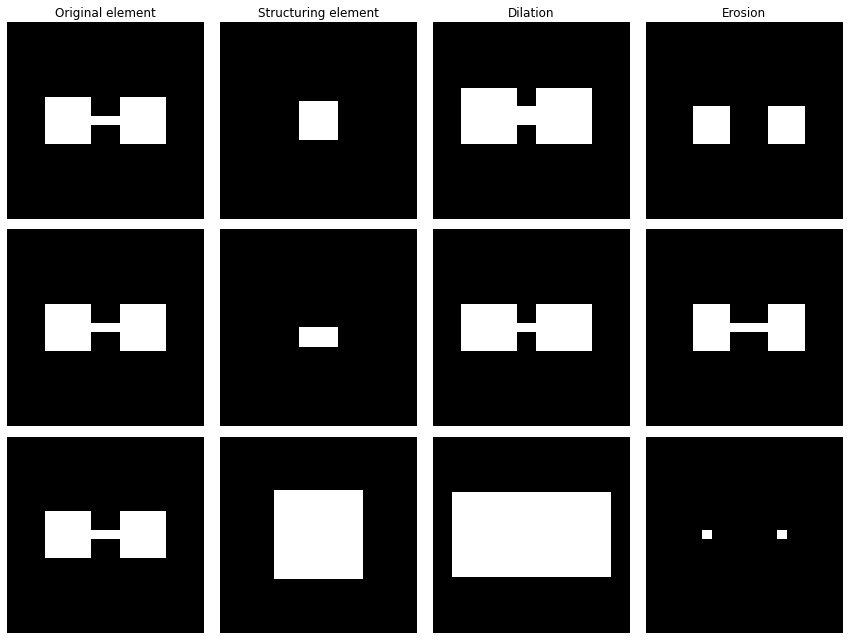

In [7]:
morphological_op_plot(dumbell)

# Malaria Cells



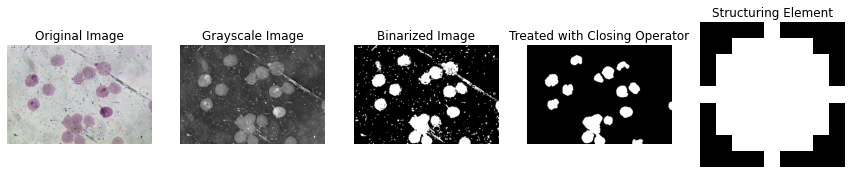

In [35]:
img = Image.open('Inputs/malaria.jpg')
malaria_GS = np.array(img.convert('L'))
threshold = 164

malaria_binary = cv2.threshold(malaria_GS, threshold, 255, cv2.THRESH_BINARY)[1]/255  # values of 0-1

strel = disk(4)    # structuring element with radius 4
malaria_opened = opening(malaria_binary, footprint=strel)      # removes holes in images
malaria_closed = closing(malaria_binary, footprint=strel)      # removes dots/noise in background

fig, ax = plt.subplots(1,5)

ax[0].imshow(img)
ax[1].imshow(malaria_GS, cmap='gray_r')
ax[2].imshow(malaria_binary, cmap='gray_r')
ax[3].imshow(malaria_closed, cmap='gray_r')
ax[4].imshow(disk(4), cmap='gray')

ax[0].set_title('Original Image')
ax[1].set_title('Grayscale Image')
ax[2].set_title('Binarized Image')
ax[3].set_title('Treated with Closing Operator')
ax[4].set_title('Structuring Element')



for i in range(5):
    ax[i].axis('off')

fig.set_size_inches(15,3)
fig.savefig('Results/Malaria.png',dpi=500)

# plt.imshow(disk(4))